# 05 — Deep Learning Detectors

This notebook demonstrates the deep learning-based anomaly detectors in Sentinel:

| Detector | Architecture | Key idea |
|----------|-------------|----------|
| `AutoencoderDetector` | LSTM encoder → latent space → LSTM decoder | Learns to reconstruct normal patterns; high reconstruction error = anomaly |
| `LNNDetector` | Liquid Neural Network encoder → LSTM decoder | Uses Liquid Time-Constant (LTC) cells for richer temporal dynamics |

Both detectors share the same API: `fit()` → `anomaly_score()` → `predict()`.

### How reconstruction-based detection works

1. Train the autoencoder on **normal data only** — it learns to compress and reconstruct typical patterns
2. At inference, feed new data through the autoencoder
3. Compute the **reconstruction error** (MSE or L1) between input and output
4. Normal data reconstructs well (low error); anomalies reconstruct poorly (high error)
5. A threshold separates normal from anomalous based on the error distribution

> **Requirements**: `pip install sentinel[deep]` (installs PyTorch).  
> For LNNDetector, also install: `pip install ncps`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentinel.visualization import AnomalyVisualizer

np.random.seed(42)

/Users/jomaver/Desktop/Code/sentinel/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Generate Synthetic Time Series

We create a time-indexed multivariate dataset with 3 features:
- A sine wave (periodic signal)
- A linear trend with noise
- Random noise

Anomalies are injected as sudden spikes at random positions after the training window.

In [2]:
n_samples = 500
n_features = 3
timestamps = pd.date_range('2025-01-15', periods=n_samples, freq='5min')
t = np.linspace(0, 10 * np.pi, n_samples)

# Normal patterns
feature_1 = np.sin(t) + np.random.normal(0, 0.1, n_samples)
feature_2 = 0.5 * t / t.max() + np.random.normal(0, 0.05, n_samples)
feature_3 = np.random.normal(0, 0.3, n_samples)

X = np.column_stack([feature_1, feature_2, feature_3])

# Inject anomalies at known positions (after training window)
anomaly_indices = np.sort(np.random.choice(range(300, n_samples), size=15, replace=False))
X[anomaly_indices] += np.random.uniform(3, 6, size=(15, n_features))

# True labels: -1 = anomaly, 1 = normal
true_labels = np.ones(n_samples, dtype=int)
true_labels[anomaly_indices] = -1

print(f"Data shape: {X.shape}")
print(f"Time range: {timestamps[0]} → {timestamps[-1]}")
print(f"Injected {len(anomaly_indices)} anomalies at indices: {anomaly_indices.tolist()}")

Data shape: (500, 3)
Time range: 2025-01-15 00:00:00 → 2025-01-16 17:35:00
Injected 15 anomalies at indices: [308, 310, 312, 317, 326, 328, 351, 364, 366, 378, 390, 396, 404, 418, 467]


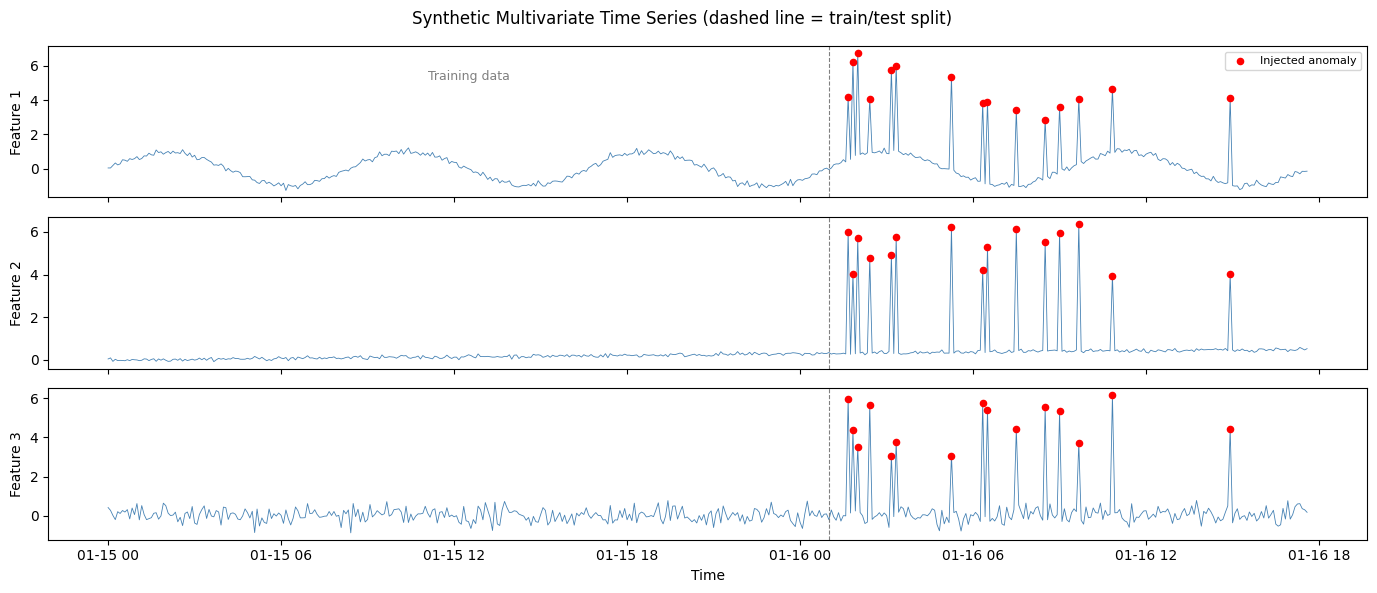

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(timestamps, X[:, i], linewidth=0.6, color='steelblue')
    ax.scatter(timestamps[anomaly_indices], X[anomaly_indices, i],
               color='red', s=20, zorder=5, label='Injected anomaly')
    ax.axvline(timestamps[300], color='gray', linestyle='--', linewidth=0.8)
    ax.set_ylabel(f'Feature {i+1}')
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)
axes[0].text(timestamps[150], ax.get_ylim()[1]*0.8, 'Training data', ha='center', fontsize=9, color='gray')
axes[-1].set_xlabel('Time')
plt.suptitle('Synthetic Multivariate Time Series (dashed line = train/test split)')
plt.tight_layout()
plt.show()

---
## 2. AutoencoderDetector

The `AutoencoderDetector` uses an LSTM-based autoencoder:
- **Encoder**: LSTM that compresses each sample into a latent representation
- **Decoder**: LSTM that reconstructs the original input from the latent space
- **Loss**: Mean Squared Error (MSE) between input and reconstruction

We train on the first 300 samples (mostly normal) and then score the entire dataset.

In [4]:
from sentinel.detectors import AutoencoderDetector

X_train = X[:300]

ae_detector = AutoencoderDetector(
    n_features=n_features,
    seq_len=1,  # each row is a single time step with n_features columns
    latent_dim=10,
    learning_rate=0.001,
    epochs=15,
    threshold_multiplier=3.0,  # threshold = mean(error) + 3 * std(error)
)

print("Training AutoencoderDetector...")
best_weights = ae_detector.fit(X_train)
print("Training complete.")

/Users/jomaver/Desktop/Code/sentinel/.venv/lib/python3.12/site-packages/rrcf/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Training AutoencoderDetector...
Epoch 0, Train Loss: 2.6780
Epoch 1, Train Loss: 1.2109
Epoch 2, Train Loss: 0.3291
Epoch 3, Train Loss: 0.1350
Epoch 4, Train Loss: 0.1109
Epoch 5, Train Loss: 0.0955
Epoch 6, Train Loss: 0.0832
Epoch 7, Train Loss: 0.0732
Epoch 8, Train Loss: 0.0654
Epoch 9, Train Loss: 0.0595
Epoch 10, Train Loss: 0.0557
Epoch 11, Train Loss: 0.0535
Epoch 12, Train Loss: 0.0524
Epoch 13, Train Loss: 0.0514
Epoch 14, Train Loss: 0.0499
Training complete.


In [5]:
# Score the full dataset
ae_scores = ae_detector.anomaly_score(X)

# Determine anomaly labels based on threshold
ae_threshold = ae_detector.threshold
ae_preds = np.where(ae_scores > ae_threshold, -1, 1) if ae_threshold else np.ones(n_samples)

print(f"Threshold: {ae_threshold:.4f}" if ae_threshold else "Threshold not set")
print(f"Anomalies detected: {(ae_preds == -1).sum()}")

Threshold: 0.1331
Anomalies detected: 114


### Visualize with AnomalyVisualizer

The static plot shows:
- **Green dots**: Normal samples (low reconstruction error)
- **Red dots**: Detected anomalies (reconstruction error above threshold)
- The gray line traces the score over time — spikes correspond to anomalous samples

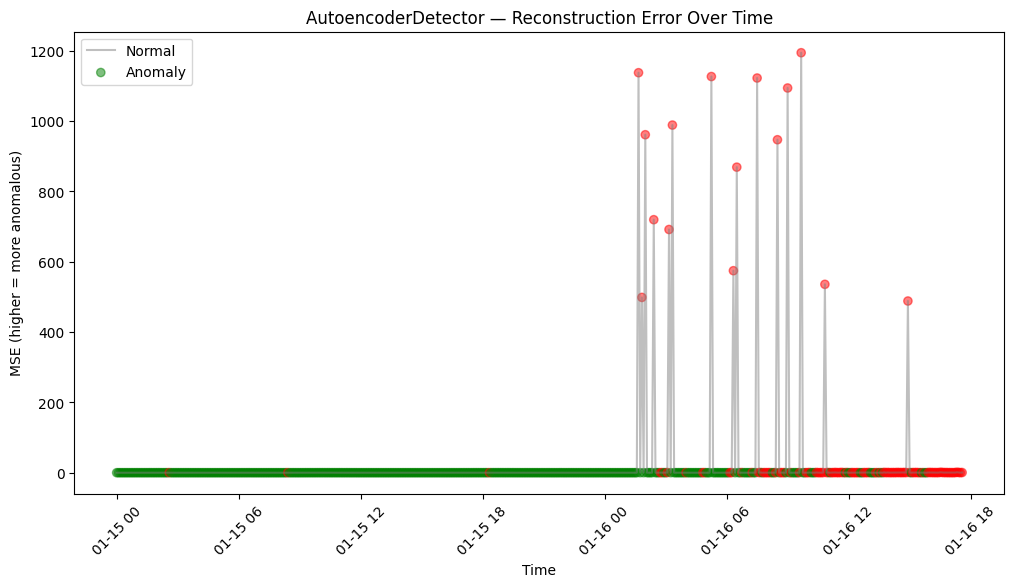

In [6]:
ae_viz_df = pd.DataFrame({
    'scores': ae_scores,
    'anomaly': ae_preds,
}, index=timestamps)

ae_viz = AnomalyVisualizer(
    anomaly_df=ae_viz_df,
    score_col='scores',
    anomaly_col='anomaly',
)

ae_viz.plot_static(
    title='AutoencoderDetector — Reconstruction Error Over Time',
    xlabel='Time',
    ylabel='MSE (higher = more anomalous)',
    legend_labels=['Normal', 'Anomaly'],
    colors={'normal': 'green', 'anomaly': 'red', 'incident': 'blue'},
)

In [7]:
# Interactive view — hover to inspect individual scores
ae_viz.plot_dynamic(
    title='AutoencoderDetector — Interactive Anomaly Scores',
    xaxis_title='Time',
    yaxis_title='Reconstruction Error (MSE)',
    colors={'normal': 'steelblue', 'anomaly': 'crimson', 'incident': 'orange'},
)

### What we're observing

- The reconstruction error is low and stable during the training period (first 300 samples) — the autoencoder learned these patterns well
- Injected anomalies produce sharp spikes in reconstruction error because the autoencoder has never seen these extreme values
- The threshold (mean + 3σ of training errors) separates the bulk of normal errors from the anomalous spikes
- Some normal samples near the boundary may be flagged (false positives) — tuning `threshold_multiplier` controls this trade-off

---
## 3. LNNDetector

The `LNNDetector` replaces the LSTM encoder with a **Liquid Time-Constant (LTC)** network. LTC cells have continuous-time dynamics that adapt their time constants based on the input, making them better at capturing complex temporal patterns.

The decoder remains an LSTM, and the loss function is L1 (mean absolute error) instead of MSE.

> Requires: `pip install ncps`

In [8]:
from sentinel.detectors import LNNDetector

lnn_detector = LNNDetector(
    n_features=n_features,
    seq_len=1,  # each row is a single time step with n_features columns
    latent_dim=8,
    learning_rate=0.001,
    epochs=15,
    threshold_multiplier=3.0,
)

print("Training LNNDetector...")
history = lnn_detector.fit(X_train, verbose=True)
print("Training complete.")

Training LNNDetector...
Epoch 1/15, Train Loss: 2.5121
Epoch 2/15, Train Loss: 2.5116
Epoch 3/15, Train Loss: 2.4142
Epoch 4/15, Train Loss: 2.1580
Epoch 5/15, Train Loss: 1.9494
Epoch 6/15, Train Loss: 1.8529
Epoch 7/15, Train Loss: 1.8029
Epoch 8/15, Train Loss: 1.7709
Epoch 9/15, Train Loss: 1.7380
Epoch 10/15, Train Loss: 1.6646
Epoch 11/15, Train Loss: 1.4572
Epoch 12/15, Train Loss: 1.3303
Epoch 13/15, Train Loss: 1.2724
Epoch 14/15, Train Loss: 1.2377
Epoch 15/15, Train Loss: 1.2172
Training complete.


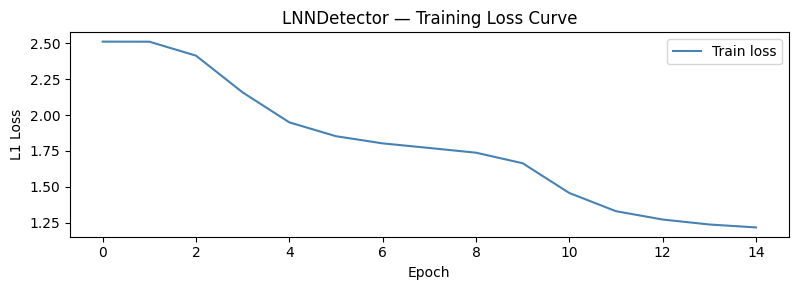

In [9]:
# Training loss curve — should decrease over epochs
plt.figure(figsize=(8, 3))
plt.plot(history['train'], label='Train loss', color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('L1 Loss')
plt.title('LNNDetector — Training Loss Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Score and classify
lnn_scores = lnn_detector.anomaly_score(X)
lnn_threshold = lnn_detector.threshold
lnn_preds = np.where(lnn_scores > lnn_threshold, -1, 1) if lnn_threshold else np.ones(n_samples)

print(f"Threshold: {lnn_threshold:.4f}" if lnn_threshold else "Threshold not set")
print(f"Anomalies detected: {(lnn_preds == -1).sum()}")

Threshold: 1.0564
Anomalies detected: 32


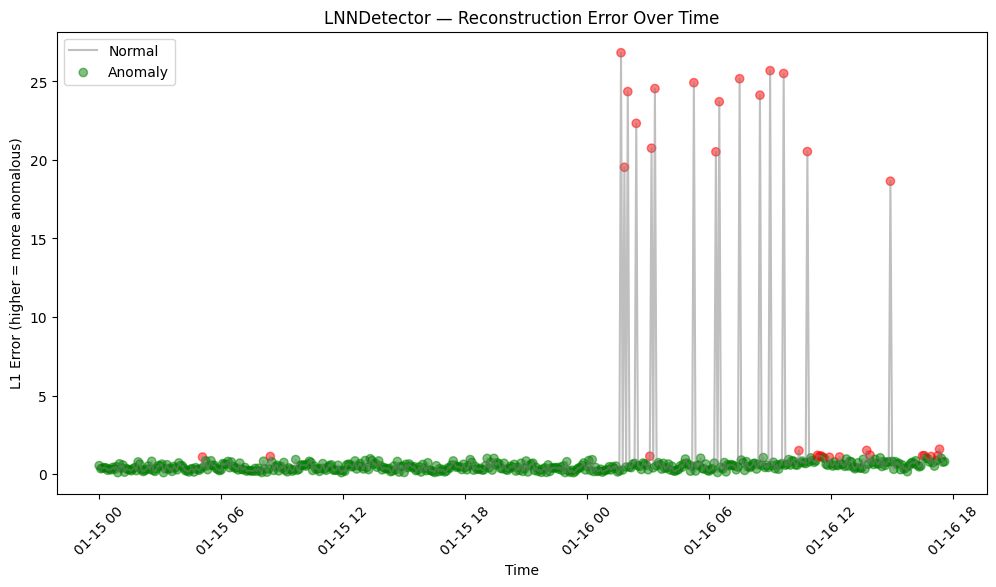

In [11]:
lnn_viz_df = pd.DataFrame({
    'scores': lnn_scores,
    'anomaly': lnn_preds,
}, index=timestamps)

lnn_viz = AnomalyVisualizer(
    anomaly_df=lnn_viz_df,
    score_col='scores',
    anomaly_col='anomaly',
)

lnn_viz.plot_static(
    title='LNNDetector — Reconstruction Error Over Time',
    xlabel='Time',
    ylabel='L1 Error (higher = more anomalous)',
    legend_labels=['Normal', 'Anomaly'],
    colors={'normal': 'green', 'anomaly': 'red', 'incident': 'blue'},
)

In [12]:
lnn_viz.plot_dynamic(
    title='LNNDetector — Interactive Anomaly Scores',
    xaxis_title='Time',
    yaxis_title='Reconstruction Error (L1)',
    colors={'normal': 'steelblue', 'anomaly': 'crimson', 'incident': 'orange'},
)

---
## 4. Comparison

Let's compare both detectors side by side. Key things to look for:
- Do both detectors flag the same anomalies?
- How do the score distributions differ?
- Which detector has better separation between normal and anomalous scores?

In [13]:
# Precision / recall comparison
def eval_detector(name, preds, true):
    tp = ((preds == -1) & (true == -1)).sum()
    fp = ((preds == -1) & (true == 1)).sum()
    fn = ((preds == 1) & (true == -1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    return {'detector': name, 'detected': (preds == -1).sum(),
            'true_positives': tp, 'false_positives': fp,
            'precision': round(prec, 3), 'recall': round(rec, 3)}

comp = pd.DataFrame([
    eval_detector('AutoencoderDetector', ae_preds, true_labels),
    eval_detector('LNNDetector', lnn_preds, true_labels),
]).set_index('detector')

comp

,detected,true_positives,false_positives,precision,recall
detector,,,,,
AutoencoderDetector,114,15,99,0.132,1.0
LNNDetector,32,15,17,0.469,1.0


### How to read the comparison

| Metric | Meaning |
|--------|---------|
| `detected` | Total samples flagged as anomalies |
| `true_positives` | Correctly identified injected anomalies |
| `false_positives` | Normal samples incorrectly flagged |
| `precision` | Of all flagged samples, how many are truly anomalous? |
| `recall` | Of all true anomalies, how many were caught? |

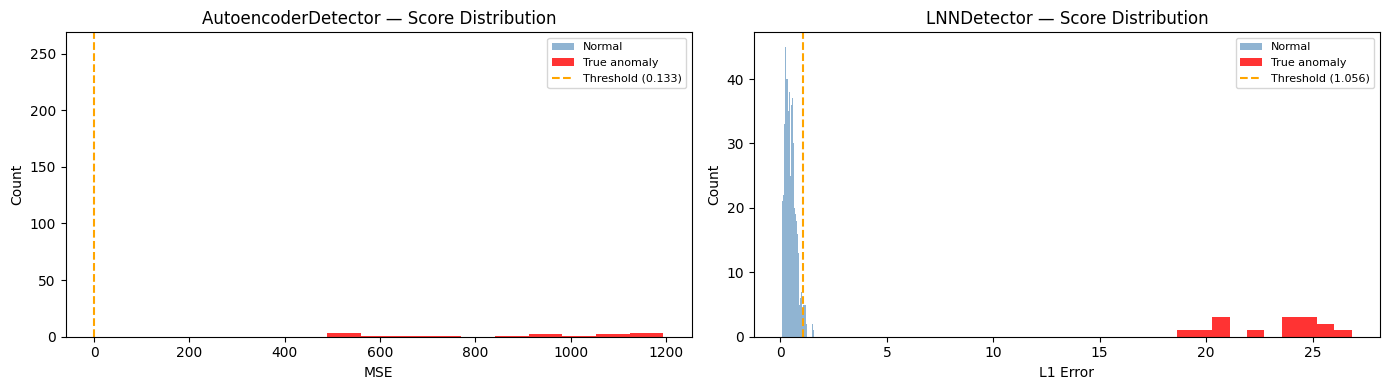

In [14]:
# Score distribution comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(ae_scores[true_labels == 1], bins=30, alpha=0.6, label='Normal', color='steelblue')
ax1.hist(ae_scores[true_labels == -1], bins=10, alpha=0.8, label='True anomaly', color='red')
if ae_threshold:
    ax1.axvline(ae_threshold, color='orange', linestyle='--', label=f'Threshold ({ae_threshold:.3f})')
ax1.set_xlabel('MSE')
ax1.set_ylabel('Count')
ax1.set_title('AutoencoderDetector — Score Distribution')
ax1.legend(fontsize=8)

ax2.hist(lnn_scores[true_labels == 1], bins=30, alpha=0.6, label='Normal', color='steelblue')
ax2.hist(lnn_scores[true_labels == -1], bins=10, alpha=0.8, label='True anomaly', color='red')
if lnn_threshold:
    ax2.axvline(lnn_threshold, color='orange', linestyle='--', label=f'Threshold ({lnn_threshold:.3f})')
ax2.set_xlabel('L1 Error')
ax2.set_ylabel('Count')
ax2.set_title('LNNDetector — Score Distribution')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

### What we're observing

The histograms show the **separation** between normal and anomalous score distributions:
- Good separation (little overlap) → the detector can reliably distinguish anomalies
- Poor separation (heavy overlap) → many false positives or missed anomalies

The orange dashed line is the threshold. Everything to the right gets flagged as anomalous.

---
## 5. Save and Load Models

Both detectors support model persistence via PyTorch's `state_dict`.

In [15]:
import tempfile, os

with tempfile.TemporaryDirectory() as tmpdir:
    ae_path = os.path.join(tmpdir, 'ae_model.pt')
    ae_detector.save_model(ae_path)
    print(f"AutoencoderDetector saved — {os.path.getsize(ae_path) / 1024:.1f} KB")

    lnn_path = os.path.join(tmpdir, 'lnn_model.pt')
    lnn_detector.save_model(lnn_path)
    print(f"LNNDetector saved — {os.path.getsize(lnn_path) / 1024:.1f} KB")

AutoencoderDetector saved — 16.6 KB
LNNDetector saved — 103.5 KB


---
## Summary

| Detector | Encoder | Loss | Strengths | Limitations |
|----------|---------|------|-----------|-------------|
| `AutoencoderDetector` | LSTM | MSE | Stable training, well-understood | May miss complex temporal patterns |
| `LNNDetector` | Liquid Time-Constant (LTC) | L1 | Richer temporal dynamics, adaptive time constants | Requires `ncps`, slower training |

Both follow the same API (`fit` / `predict` / `anomaly_score`), making them interchangeable in your pipeline. Use `AnomalyVisualizer` to inspect results with both static and interactive plots.